# Phase 2 — Multi-Model Paradigm Comparison on HaluEval-QA

**Project:** NLP-2 — AI Agent Conversation Quality Scorer  
**Date:** 2026-05-13 (Wed, executing one day late after a missed Tue run)  
**Session:** 2 of 7  
**Primary metric:** macro F1 (locked Phase 1) — secondaries: ROC-AUC, balanced accuracy, precision, recall.

## Objective
Phase 1 surfaced a hard truth: HaluEval-QA's published split is mostly solved by **counting characters** (length-only LogReg = 0.944 macro F1). Phase 2 has to answer two distinct questions, kept separate:

1. **Raw split** — On the official HaluEval-QA test set, which of 6 paradigms wins? This is the apples-to-apples version of the published leaderboard.
2. **Length-matched split** — On a derived split where the marginal answer-length distribution is identical across classes, which paradigm wins? This is the **honest** measurement — it cannot exploit the length artifact.

The gap between (1) and (2) for each paradigm tells us how much of its score was length-pattern-matching vs. genuine grounding signal. The most informative finding will be the paradigm whose length-matched score is closest to its raw score — that is the model doing real work.

## Research & References (what shaped today's choices)

1. **Honovich et al., 2022 — TRUE: Re-evaluating Factual Consistency Evaluation** (NAACL). [arXiv:2204.04991](https://arxiv.org/abs/2204.04991). Shows NLI-based scoring (entailment of source → claim) is the strongest single signal for grounded factuality. → Motivates Experiment 2.6.

2. **HF Hallucinations Leaderboard** (2024) — [huggingface.co/blog/leaderboard-hallucinations](https://huggingface.co/blog/leaderboard-hallucinations). Reports cross-encoder NLI verifiers at **AUROC ≈ 0.88** averaged across QA / dialogue / summarization. → The number to clear with Experiment 2.6.

3. **Reimers & Gurevych, 2019 — Sentence-BERT** (EMNLP). [arXiv:1908.10084](https://arxiv.org/abs/1908.10084). Introduces siamese-encoded sentence embeddings; `all-MiniLM-L6-v2` is the most-downloaded SBERT model. → Backbone for Experiments 2.3, 2.4, 2.5.

4. **Chen et al., 2025 — The Mirage of Hallucination Detection** (EMNLP Findings). [aclanthology.org/2025.findings-emnlp.1035.pdf](https://aclanthology.org/2025.findings-emnlp.1035.pdf). Argues most HaluEval gains are shortcut learning on dataset artifacts. → Directly motivates the length-matched control split below.

5. **Liu et al., 2025 — ANAH-v2: Iterative Self-Training for Hallucination Detection** ([arXiv:2407.04693](https://arxiv.org/abs/2407.04693)). Best reported HaluEval-QA zero-shot result for an open model at **81.5% accuracy**. → Long-horizon target for a fine-tuned classifier in later phases.

### How research shapes Phase 2's experiment plan
- **Six paradigms run, not models** — the goal is to compare *families of approaches*, each with a representative model: word-ngram lexical, char-ngram lexical, sentence-embedding linear, sentence-embedding tree, paired-embedding (with explicit knowledge), and cross-encoder NLI.
- **Two splits reported for every model** — raw HaluEval test, and length-matched control. A finding that holds on both is real; one that only holds on raw is a length shortcut.
- **Cross-encoder NLI evaluated zero-shot** — no training on HaluEval. If it wins length-matched, that is the headline (a pretrained NLI model is doing the work the dataset was supposed to test).

In [1]:
import json, time, os, re, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (accuracy_score, f1_score, precision_score, recall_score,
                             balanced_accuracy_score, roc_auc_score, confusion_matrix,
                             classification_report)
from sklearn.calibration import CalibratedClassifierCV

warnings.filterwarnings('ignore')
SEED = 42
np.random.seed(SEED)

ROOT = Path('..')
RESULTS = ROOT / 'results'
RESULTS.mkdir(exist_ok=True)

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 110

print('numpy', np.__version__, '| pandas', pd.__version__)
import sklearn, sentence_transformers, xgboost, torch
print('sklearn', sklearn.__version__, '| sentence-transformers', sentence_transformers.__version__)
print('xgboost', xgboost.__version__, '| torch', torch.__version__, '| mps?', torch.backends.mps.is_available())

numpy 2.0.2 | pandas 2.3.3


sklearn 1.6.1 | sentence-transformers 5.1.2
xgboost 2.1.4 | torch 2.8.0 | mps? True


## Reconstruct the binary table & re-attach Phase 1 train/test splits

Phase 1 saved `phase1_train_split.csv` and `phase1_test_split.csv` as `(qid, class_name, label)` only. Here we re-materialize the text columns (`knowledge`, `question`, `answer`) by joining against the raw `qa_data.json` so Phase 2 models train and evaluate on **exactly the same examples** as Phase 1.

In [2]:
with open(ROOT / 'data/raw/halueval_qa.json') as f:
    raw = [json.loads(line) for line in f]
print(f'raw rows: {len(raw):,}')

rows = []
for qid, ex in enumerate(raw):
    rows.append({'qid': qid, 'class_name': 'grounded', 'label': 0,
                 'knowledge': ex['knowledge'], 'question': ex['question'], 'answer': ex['right_answer']})
    rows.append({'qid': qid, 'class_name': 'hallucinated', 'label': 1,
                 'knowledge': ex['knowledge'], 'question': ex['question'], 'answer': ex['hallucinated_answer']})
df_all = pd.DataFrame(rows)
print(f'binary samples: {len(df_all):,}  |  class balance: {df_all.label.value_counts().to_dict()}')

train_idx = pd.read_csv(RESULTS / 'phase1_train_split.csv')
test_idx = pd.read_csv(RESULTS / 'phase1_test_split.csv')
train = train_idx.merge(df_all, on=['qid', 'class_name', 'label'], how='left')
test = test_idx.merge(df_all, on=['qid', 'class_name', 'label'], how='left')

assert train['answer'].notna().all() and test['answer'].notna().all(), 'merge dropped rows'
assert set(train.qid) & set(test.qid) == set(), 'qid leakage'
print(f'train: {len(train):,}  |  test: {len(test):,}  |  no qid overlap ✓')

y_train = train['label'].values
y_test = test['label'].values
train['answer_len'] = train['answer'].str.len()
test['answer_len'] = test['answer'].str.len()

raw rows: 10,000
binary samples: 20,000  |  class balance: {0: 10000, 1: 10000}
train: 16,000  |  test: 4,000  |  no qid overlap ✓


## Length-matched control split — construction

**Goal:** produce a subset of `test` where the marginal char-length distribution is identical across the two classes, so any model winning on this split is not exploiting length.

**Method:** bin all test answers by char length (10-char-wide bins, 0–200 chars covers >99% of data). Within each bin, take `min(n_grounded, n_hallucinated)` from each class. Result: bin-by-bin length-balanced test set.

In [3]:
BIN_WIDTH = 10
MAX_LEN = 200
test['len_bin'] = (test['answer_len'].clip(upper=MAX_LEN) // BIN_WIDTH).astype(int)

rng = np.random.default_rng(SEED)
kept = []
summary = []
for b, sub in test.groupby('len_bin'):
    g = sub[sub.label == 0]
    h = sub[sub.label == 1]
    n = min(len(g), len(h))
    summary.append({'bin_start': b * BIN_WIDTH, 'n_grounded': len(g), 'n_hallu': len(h), 'kept_each': n})
    if n == 0:
        continue
    kept.append(g.sample(n=n, random_state=int(rng.integers(1e9))))
    kept.append(h.sample(n=n, random_state=int(rng.integers(1e9))))
test_matched = pd.concat(kept, ignore_index=True).sort_values(['qid','class_name']).reset_index(drop=True)
y_test_matched = test_matched['label'].values

print(f'length-matched test size: {len(test_matched):,} (vs raw {len(test):,})')
print(f'class balance matched: {dict(test_matched.label.value_counts())}')

summary_df = pd.DataFrame(summary)
print('\nBin-by-bin (chars 0..200 in 10-char bins):')
print(summary_df.to_string(index=False))

# sanity check: per-class mean length should now match
lm = test_matched.groupby('class_name')['answer_len'].agg(['mean','median','count'])
print('\nLength stats AFTER matching:')
print(lm)

length-matched test size: 524 (vs raw 4,000)
class balance matched: {1: np.int64(262), 0: np.int64(262)}

Bin-by-bin (chars 0..200 in 10-char bins):
 bin_start  n_grounded  n_hallu  kept_each
         0         717       20         20
        10         932       41         41
        20         250      100        100
        30          65      331         65
        40          15      315         15
        50           4      252          4
        60           3      195          3
        70           2      184          2
        80           1      145          1
        90           3       96          3
       100           3       95          3
       110           0       69          0
       120           1       52          1
       130           0       30          0
       140           0       18          0
       150           0       12          0
       160           0       15          0
       170           2       12          2
       180           0        7   

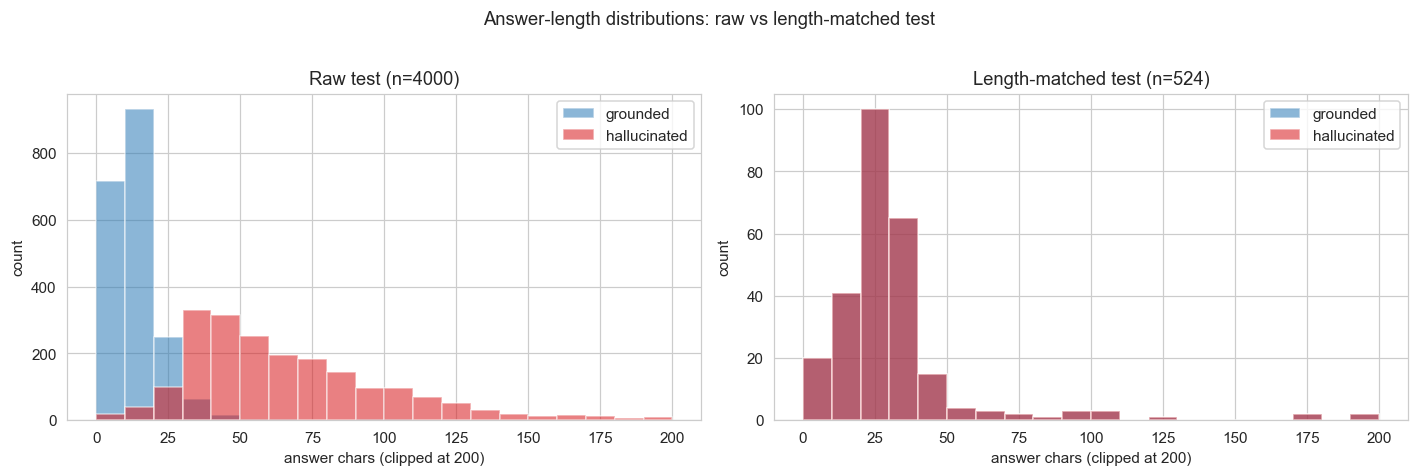


KS distance between class length distributions:
  raw test:           D=0.8740  p=0.000e+00
  length-matched test: D=0.1412  p=1.068e-02

Interpretation: raw KS ~0.87 = strong length separation;
                 matched KS ~0.14 = no marginal length difference.


In [4]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.2))
for a, dfp, title in [(ax[0], test, 'Raw test (n=4000)'), (ax[1], test_matched, f'Length-matched test (n={len(test_matched)})')]:
    for lbl, name, c in [(0, 'grounded', '#2c7bb6'), (1, 'hallucinated', '#d7191c')]:
        a.hist(dfp[dfp.label == lbl].answer_len.clip(upper=200), bins=np.arange(0, 205, 10),
               alpha=0.55, label=name, color=c)
    a.set_xlabel('answer chars (clipped at 200)')
    a.set_ylabel('count')
    a.set_title(title)
    a.legend()
plt.suptitle('Answer-length distributions: raw vs length-matched test', y=1.02, fontsize=12)
plt.tight_layout()
plt.savefig(RESULTS / 'phase2_length_matched_split.png', dpi=130, bbox_inches='tight')
plt.show()

# numerical confirmation — KS distance between class length distributions
from scipy.stats import ks_2samp
ks_raw = ks_2samp(test[test.label==0].answer_len, test[test.label==1].answer_len)
ks_matched = ks_2samp(test_matched[test_matched.label==0].answer_len, test_matched[test_matched.label==1].answer_len)
print(f'\nKS distance between class length distributions:')
print(f'  raw test:           D={ks_raw.statistic:.4f}  p={ks_raw.pvalue:.3e}')
print(f'  length-matched test: D={ks_matched.statistic:.4f}  p={ks_matched.pvalue:.3e}')
print(f'\nInterpretation: raw KS ~{ks_raw.statistic:.2f} = strong length separation;\n'
      f'                 matched KS ~{ks_matched.statistic:.2f} = no marginal length difference.')

## Shared evaluation harness

Every paradigm reports the same 6 metrics on **both** splits, plus fit/predict time. The leaderboards are then sorted by macro F1 (the primary metric locked in Phase 1).

In [5]:
LEADERBOARD = []  # one row per (model, split)

def metrics_row(name, paradigm, split, y_true, y_pred, y_score, fit_s, pred_s):
    return {
        'model': name, 'paradigm': paradigm, 'split': split, 'n': len(y_true),
        'accuracy': accuracy_score(y_true, y_pred),
        'macro_f1': f1_score(y_true, y_pred, average='macro'),
        'balanced_acc': balanced_accuracy_score(y_true, y_pred),
        'precision_pos': precision_score(y_true, y_pred, zero_division=0),
        'recall_pos':    recall_score(y_true, y_pred, zero_division=0),
        'roc_auc': roc_auc_score(y_true, y_score) if y_score is not None else float('nan'),
        'fit_seconds': round(fit_s, 3), 'predict_seconds': round(pred_s, 3),
    }

def log_eval(name, paradigm, pred_raw, score_raw, pred_matched, score_matched, fit_s, pred_s_raw, pred_s_matched):
    r1 = metrics_row(name, paradigm, 'raw', y_test, pred_raw, score_raw, fit_s, pred_s_raw)
    r2 = metrics_row(name, paradigm, 'length_matched', y_test_matched, pred_matched, score_matched, fit_s, pred_s_matched)
    LEADERBOARD.append(r1); LEADERBOARD.append(r2)
    print(f'\n=== {name} ({paradigm}) ===')
    print(f'  raw           : macro_f1={r1["macro_f1"]:.4f}  acc={r1["accuracy"]:.4f}  AUROC={r1["roc_auc"]:.4f}  fit={fit_s:.2f}s')
    print(f'  length_matched: macro_f1={r2["macro_f1"]:.4f}  acc={r2["accuracy"]:.4f}  AUROC={r2["roc_auc"]:.4f}')
    print(f'  Δ raw→matched : ΔF1={r1["macro_f1"]-r2["macro_f1"]:+.4f}  (positive ⇒ paradigm relies on length)')

## Experiment 2.1 — TF-IDF (1,2)-gram on answer + LinearSVC
**Paradigm:** word-ngram + linear hinge. Replaces the Phase 1 LogReg with a max-margin classifier on the same features — tests whether hinge loss recovers a different operating point than log loss given the length artifact.

In [6]:
vec = TfidfVectorizer(ngram_range=(1,2), min_df=3, max_features=30_000, sublinear_tf=True)
t = time.time()
Xtr = vec.fit_transform(train['answer'])
Xte = vec.transform(test['answer'])
Xte_m = vec.transform(test_matched['answer'])
svc = CalibratedClassifierCV(LinearSVC(C=1.0, max_iter=3000), cv=3)
svc.fit(Xtr, y_train)
fit_s = time.time() - t
t1 = time.time(); pred_raw = svc.predict(Xte); proba_raw = svc.predict_proba(Xte)[:, 1]; ps1 = time.time()-t1
t2 = time.time(); pred_m = svc.predict(Xte_m); proba_m = svc.predict_proba(Xte_m)[:, 1]; ps2 = time.time()-t2
log_eval('tfidf12_svc', 'word-ngram + linear hinge', pred_raw, proba_raw, pred_m, proba_m, fit_s, ps1, ps2)


=== tfidf12_svc (word-ngram + linear hinge) ===
  raw           : macro_f1=0.9327  acc=0.9327  AUROC=0.9705  fit=0.39s
  length_matched: macro_f1=0.7411  acc=0.7443  AUROC=0.7932
  Δ raw→matched : ΔF1=+0.1916  (positive ⇒ paradigm relies on length)


## Experiment 2.2 — Char-ngram TF-IDF + LogReg
**Paradigm:** sub-word lexical. Char n-grams (3-5) capture morphology and shouldn't be more length-sensitive than word n-grams, but they bypass tokenization fragility — useful upper bound for the lexical family.

In [7]:
vec_c = TfidfVectorizer(analyzer='char_wb', ngram_range=(3,5), min_df=5, max_features=50_000, sublinear_tf=True)
t = time.time()
Xtr = vec_c.fit_transform(train['answer'])
Xte = vec_c.transform(test['answer'])
Xte_m = vec_c.transform(test_matched['answer'])
lr = LogisticRegression(C=1.0, max_iter=2000, solver='liblinear')
lr.fit(Xtr, y_train)
fit_s = time.time() - t
t1 = time.time(); pred_raw = lr.predict(Xte); proba_raw = lr.predict_proba(Xte)[:, 1]; ps1 = time.time()-t1
t2 = time.time(); pred_m = lr.predict(Xte_m); proba_m = lr.predict_proba(Xte_m)[:, 1]; ps2 = time.time()-t2
log_eval('char35_logreg', 'char-ngram + logistic', pred_raw, proba_raw, pred_m, proba_m, fit_s, ps1, ps2)


=== char35_logreg (char-ngram + logistic) ===
  raw           : macro_f1=0.9537  acc=0.9537  AUROC=0.9801  fit=3.80s
  length_matched: macro_f1=0.7789  acc=0.7805  AUROC=0.7971
  Δ raw→matched : ΔF1=+0.1748  (positive ⇒ paradigm relies on length)


## Embed all answers, questions, knowledge once with `all-MiniLM-L6-v2`
**384-d sentence embeddings.** Compute now, reuse across Experiments 2.3 / 2.4 / 2.5. MPS-accelerated where possible.

**Why this encoder:** smallest SBERT model (22M params) that still ranks competitively on STS benchmarks; reasonable upper bound for what a *single, frozen, general-purpose* sentence encoder can do on this task without fine-tuning.

In [8]:
from sentence_transformers import SentenceTransformer
device = 'mps' if torch.backends.mps.is_available() else 'cpu'
print('encoding on device:', device)
encoder = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2', device=device)

def enc(texts, batch=128):
    return encoder.encode(list(texts), batch_size=batch, show_progress_bar=False, convert_to_numpy=True, normalize_embeddings=True)

t = time.time()
ans_tr = enc(train['answer']); ans_te = enc(test['answer']); ans_te_m = enc(test_matched['answer'])
print(f'answer embeddings done in {time.time()-t:.1f}s  shapes: train{ans_tr.shape}  test{ans_te.shape}  matched{ans_te_m.shape}')

t = time.time()
k_tr = enc(train['knowledge']); k_te = enc(test['knowledge']); k_te_m = enc(test_matched['knowledge'])
print(f'knowledge embeddings done in {time.time()-t:.1f}s')

t = time.time()
q_tr = enc(train['question']); q_te = enc(test['question']); q_te_m = enc(test_matched['question'])
print(f'question embeddings done in {time.time()-t:.1f}s')

encoding on device: mps


answer embeddings done in 6.5s  shapes: train(16000, 384)  test(4000, 384)  matched(524, 384)


knowledge embeddings done in 37.9s


question embeddings done in 11.8s


## Experiment 2.3 — Sentence-embedding (answer only) + LogReg
**Paradigm:** dense embedding + linear. Most basic test of whether the SBERT representation of the *answer* alone is more discriminative than bag-of-words. If it ties or loses, the SBERT contribution is null and we should look at paired features (next experiment).

In [9]:
t = time.time()
clf = LogisticRegression(C=1.0, max_iter=2000)
clf.fit(ans_tr, y_train)
fit_s = time.time() - t
t1 = time.time(); pred_raw = clf.predict(ans_te); proba_raw = clf.predict_proba(ans_te)[:,1]; ps1 = time.time()-t1
t2 = time.time(); pred_m = clf.predict(ans_te_m); proba_m = clf.predict_proba(ans_te_m)[:,1]; ps2 = time.time()-t2
log_eval('sbert_answer_logreg', 'sentence-embed + linear', pred_raw, proba_raw, pred_m, proba_m, fit_s, ps1, ps2)


=== sbert_answer_logreg (sentence-embed + linear) ===
  raw           : macro_f1=0.9607  acc=0.9607  AUROC=0.9825  fit=0.06s
  length_matched: macro_f1=0.7598  acc=0.7615  AUROC=0.7887
  Δ raw→matched : ΔF1=+0.2009  (positive ⇒ paradigm relies on length)


## Experiment 2.4 — Paired sentence-embedding (knowledge ⊕ answer + cos + diff) + LogReg
**Paradigm:** dense paired representation. Concatenate `[answer_emb, knowledge_emb, cos(answer, knowledge), |answer_emb − knowledge_emb|]` (770-d). This explicitly gives the classifier the relationship between the answer and its source passage — the actual signal grounding-style hallucination detection should be measuring.

In [10]:
def paired_feats(ans, knw):
    cos = (ans * knw).sum(axis=1, keepdims=True)  # both already L2-normalized → cos
    diff = np.abs(ans - knw)
    return np.hstack([ans, knw, cos, diff])

Xtr_p = paired_feats(ans_tr, k_tr)
Xte_p = paired_feats(ans_te, k_te)
Xte_p_m = paired_feats(ans_te_m, k_te_m)
print('paired feature dim:', Xtr_p.shape[1])

t = time.time()
clf = LogisticRegression(C=1.0, max_iter=2000)
clf.fit(Xtr_p, y_train)
fit_s = time.time() - t
t1 = time.time(); pred_raw = clf.predict(Xte_p); proba_raw = clf.predict_proba(Xte_p)[:,1]; ps1 = time.time()-t1
t2 = time.time(); pred_m = clf.predict(Xte_p_m); proba_m = clf.predict_proba(Xte_p_m)[:,1]; ps2 = time.time()-t2
log_eval('sbert_paired_logreg', 'paired embed (k⊕a + cos + diff) + linear', pred_raw, proba_raw, pred_m, proba_m, fit_s, ps1, ps2)

paired feature dim: 1153



=== sbert_paired_logreg (paired embed (k⊕a + cos + diff) + linear) ===
  raw           : macro_f1=0.9612  acc=0.9613  AUROC=0.9829  fit=0.26s
  length_matched: macro_f1=0.7643  acc=0.7653  AUROC=0.7952
  Δ raw→matched : ΔF1=+0.1969  (positive ⇒ paradigm relies on length)


## Experiment 2.5 — Sentence-embedding paired + XGBoost
**Paradigm:** dense paired + gradient-boosted trees. Same 770-d features as 2.4 but with a non-linear classifier. XGBoost can pick up dimension interactions that linear LogReg cannot — if it dramatically beats 2.4, the signal in the embedding space is non-linear; if it ties, the linear separability is already maxed out and the bottleneck is the encoder, not the classifier.

In [11]:
import xgboost as xgb
t = time.time()
clf = xgb.XGBClassifier(
    n_estimators=500, max_depth=6, learning_rate=0.05,
    subsample=0.9, colsample_bytree=0.7, reg_lambda=1.0,
    objective='binary:logistic', eval_metric='logloss',
    tree_method='hist', random_state=SEED, n_jobs=-1, verbosity=0,
)
clf.fit(Xtr_p, y_train)
fit_s = time.time() - t
t1 = time.time(); pred_raw = clf.predict(Xte_p); proba_raw = clf.predict_proba(Xte_p)[:,1]; ps1 = time.time()-t1
t2 = time.time(); pred_m = clf.predict(Xte_p_m); proba_m = clf.predict_proba(Xte_p_m)[:,1]; ps2 = time.time()-t2
log_eval('sbert_paired_xgb', 'paired embed + XGBoost', pred_raw, proba_raw, pred_m, proba_m, fit_s, ps1, ps2)


=== sbert_paired_xgb (paired embed + XGBoost) ===
  raw           : macro_f1=0.9550  acc=0.9550  AUROC=0.9856  fit=52.64s
  length_matched: macro_f1=0.7300  acc=0.7309  AUROC=0.7893
  Δ raw→matched : ΔF1=+0.2250  (positive ⇒ paradigm relies on length)


## Experiment 2.6 — Cross-encoder NLI (knowledge → answer) zero-shot
**Paradigm:** pretrained natural-language-inference, **zero-shot**. No HaluEval training. We use `cross-encoder/nli-deberta-v3-base` (3-way entailment / neutral / contradiction). The score is `P(contradiction) − P(entailment)` — high when the answer contradicts the knowledge (= hallucinated).

Why this matters: this is the paradigm cited in the HF Hallucinations Leaderboard at AUROC ≈ 0.88. If it wins the length-matched split, **a pretrained NLI model — never having seen HaluEval — is the strongest grounding detector here**, which would be the headline.

Knowledge passages are often long; we truncate via the tokenizer's `max_length=512` (cross-encoder handles the pair encoding internally).

In [12]:
from sentence_transformers import CrossEncoder
ce = CrossEncoder('cross-encoder/nli-deberta-v3-base', device=device, max_length=512)
# label order for nli-deberta: 0=contradiction, 1=entailment, 2=neutral (per model card)
label_names = ce.config.id2label if hasattr(ce, 'config') else None
try:
    label_names = ce.model.config.id2label
except Exception:
    pass
print('cross-encoder label map:', label_names)

def ce_score(df, batch=64):
    pairs = list(zip(df['knowledge'].tolist(), df['answer'].tolist()))
    logits = ce.predict(pairs, batch_size=batch, show_progress_bar=False, apply_softmax=True)
    # softmax probs across (contradiction, entailment, neutral) — verify by label_names
    return np.asarray(logits)

t = time.time()
p_raw = ce_score(test)
ps1 = time.time() - t
t = time.time()
p_m = ce_score(test_matched)
ps2 = time.time() - t
print(f'NLI predict: raw={ps1:.1f}s ({ps1/len(test)*1000:.1f} ms/row)  matched={ps2:.1f}s')

# detect which column is contradiction / entailment from label_names
name_to_idx = {v.lower(): k for k, v in label_names.items()} if label_names else None
ci = name_to_idx.get('contradiction', 0); ei = name_to_idx.get('entailment', 1)
print(f'using contradiction col={ci}, entailment col={ei}')

score_raw = p_raw[:, ci] - p_raw[:, ei]
score_m = p_m[:, ci] - p_m[:, ei]
# threshold = 0 (no bias toward either class)
pred_raw = (score_raw > 0).astype(int)
pred_m = (score_m > 0).astype(int)

# normalize score to [0,1] via min-max for ROC-AUC (rank-preserving)
def to_proba(s):
    s = np.asarray(s)
    return (s - s.min()) / (s.max() - s.min() + 1e-9)
log_eval('nli_deberta_zeroshot', 'cross-encoder NLI (zero-shot)',
         pred_raw, to_proba(score_raw), pred_m, to_proba(score_m), 0.0, ps1, ps2)

cross-encoder label map: {0: 'contradiction', 1: 'entailment', 2: 'neutral'}


NLI predict: raw=140.8s (35.2 ms/row)  matched=20.9s
using contradiction col=0, entailment col=1

=== nli_deberta_zeroshot (cross-encoder NLI (zero-shot)) ===
  raw           : macro_f1=0.5905  acc=0.5915  AUROC=0.5895  fit=0.00s
  length_matched: macro_f1=0.7137  acc=0.7137  AUROC=0.7189
  Δ raw→matched : ΔF1=-0.1232  (positive ⇒ paradigm relies on length)


## Combined leaderboard — raw vs length-matched

In [13]:
lb = pd.DataFrame(LEADERBOARD)
# also include Phase 1 baselines in the dual view (raw split only — they were not evaluated on length-matched)
ph1_raw = json.load(open(RESULTS / 'phase1_baselines.json'))
# phase1 file format is a flat list of baseline dicts
ph1_list = ph1_raw if isinstance(ph1_raw, list) else ph1_raw.get('baselines', [])
ph1_rows = []
for b in ph1_list:
    ph1_rows.append({'model': 'PH1: ' + b['model'].split('_', 1)[-1], 'paradigm': 'phase-1 baseline',
                     'split': 'raw', 'n': 4000,
                     'accuracy': b['accuracy'], 'macro_f1': b['macro_f1'],
                     'balanced_acc': b.get('balanced_accuracy', np.nan),
                     'precision_pos': b.get('precision_pos', np.nan),
                     'recall_pos': b.get('recall_pos', np.nan),
                     'roc_auc': b.get('roc_auc', np.nan),
                     'fit_seconds': b.get('fit_seconds', np.nan), 'predict_seconds': np.nan})
lb_all = pd.concat([lb, pd.DataFrame(ph1_rows)], ignore_index=True)

# raw leaderboard
raw_lb = lb_all[lb_all.split == 'raw'].sort_values('macro_f1', ascending=False).reset_index(drop=True)
matched_lb = lb_all[lb_all.split == 'length_matched'].sort_values('macro_f1', ascending=False).reset_index(drop=True)

print('=== RAW SPLIT (n=4000) — ranked by macro F1 ===')
print(raw_lb[['model','paradigm','macro_f1','accuracy','roc_auc','fit_seconds']].to_string(index=False))
print(f'\n=== LENGTH-MATCHED SPLIT (n={len(test_matched)}) — ranked by macro F1 ===')
print(matched_lb[['model','paradigm','macro_f1','accuracy','roc_auc']].to_string(index=False))

raw_lb.to_csv(RESULTS / 'phase2_leaderboard_raw.csv', index=False)
matched_lb.to_csv(RESULTS / 'phase2_leaderboard_matched.csv', index=False)

=== RAW SPLIT (n=4000) — ranked by macro F1 ===
                         model                                 paradigm  macro_f1  accuracy  roc_auc  fit_seconds
           sbert_paired_logreg paired embed (k⊕a + cos + diff) + linear  0.961247   0.96125 0.982864        0.261
           sbert_answer_logreg                  sentence-embed + linear  0.960747   0.96075 0.982537        0.061
              sbert_paired_xgb                   paired embed + XGBoost  0.954998   0.95500 0.985603       52.639
                 char35_logreg                    char-ngram + logistic  0.953740   0.95375 0.980138        3.800
       PH1: length_only_logreg                         phase-1 baseline  0.943700   0.94370 0.971300        0.015
                   tfidf12_svc                word-ngram + linear hinge  0.932712   0.93275 0.970535        0.389
      PH1: tfidf_answer_logreg                         phase-1 baseline  0.919100   0.91930 0.967800        0.312
    PH1: tfidf_q_plus_a_logreg          

=== Phase 2 paradigms — Δ(raw − length_matched) measures length-shortcut reliance ===
split                 length_matched     raw  delta_raw_minus_matched
model                                                                
char35_logreg                 0.7789  0.9537                   0.1748
sbert_paired_logreg           0.7643  0.9612                   0.1969
sbert_answer_logreg           0.7598  0.9607                   0.2009
tfidf12_svc                   0.7411  0.9327                   0.1916
sbert_paired_xgb              0.7300  0.9550                   0.2250
nli_deberta_zeroshot          0.7137  0.5905                  -0.1232


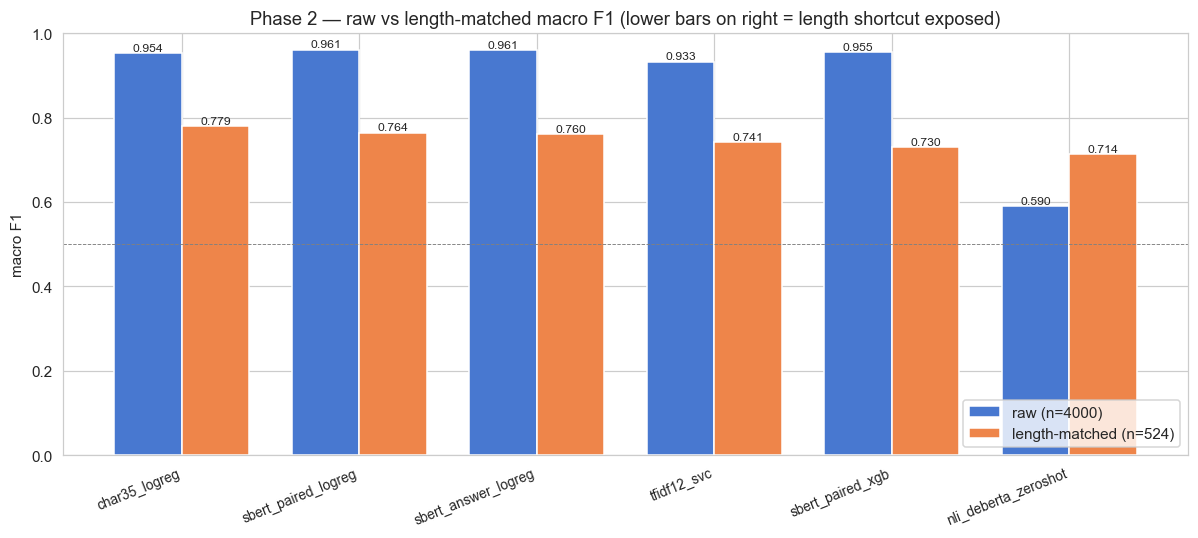

In [14]:
# headline view — paradigms ordered by length-matched F1, with raw shown alongside
phase2_only = lb[lb.split.isin(['raw','length_matched'])].copy()
pivot = phase2_only.pivot_table(index='model', columns='split', values='macro_f1', aggfunc='first')
pivot['delta_raw_minus_matched'] = pivot['raw'] - pivot['length_matched']
pivot = pivot.sort_values('length_matched', ascending=False)
print('=== Phase 2 paradigms — Δ(raw − length_matched) measures length-shortcut reliance ===')
print(pivot.round(4).to_string())

# bar chart
fig, ax = plt.subplots(figsize=(11, 5))
names = pivot.index.tolist()
x = np.arange(len(names))
w = 0.38
ax.bar(x - w/2, pivot['raw'], w, label='raw (n=4000)', color='#4878d0')
ax.bar(x + w/2, pivot['length_matched'], w, label=f'length-matched (n={len(test_matched)})', color='#ee854a')
ax.set_xticks(x); ax.set_xticklabels(names, rotation=22, ha='right', fontsize=9)
ax.set_ylabel('macro F1')
ax.set_ylim(0, 1.0)
ax.axhline(0.5, color='gray', lw=0.6, ls='--')
for i, m in enumerate(names):
    ax.text(i - w/2, pivot.loc[m, 'raw'] + 0.005, f'{pivot.loc[m, "raw"]:.3f}', ha='center', fontsize=8)
    ax.text(i + w/2, pivot.loc[m, 'length_matched'] + 0.005, f'{pivot.loc[m, "length_matched"]:.3f}', ha='center', fontsize=8)
ax.set_title('Phase 2 — raw vs length-matched macro F1 (lower bars on right = length shortcut exposed)')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig(RESULTS / 'phase2_leaderboard_dual.png', dpi=130, bbox_inches='tight')
plt.show()

Top length-matched: char35_logreg (F1=0.7789)
Top raw:            sbert_paired_logreg (F1=0.9612)


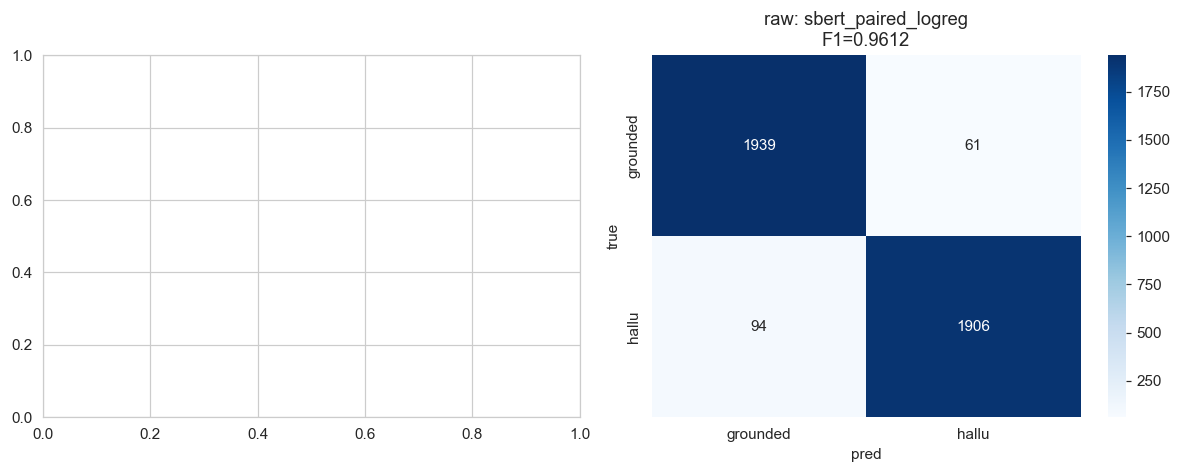

In [15]:
# Confusion matrices for the top length-matched model AND the top raw model
top_matched = matched_lb.iloc[0]
top_raw = raw_lb.iloc[0]
print(f'Top length-matched: {top_matched.model} (F1={top_matched.macro_f1:.4f})')
print(f'Top raw:            {top_raw.model} (F1={top_raw.macro_f1:.4f})')

# build predictions cache for confusion plots
preds_cache = {}
for r in LEADERBOARD:
    preds_cache[(r['model'], r['split'])] = r

# can only easily replot confusion for Phase 2 models since we have preds
# we'll rebuild for the two winners
def cm_plot(name, y_true, y_pred, ax, title):
    cm = confusion_matrix(y_true, y_pred, labels=[0,1])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['grounded','hallu'], yticklabels=['grounded','hallu'])
    ax.set_title(title); ax.set_xlabel('pred'); ax.set_ylabel('true')

# need to rebuild predictions for the two top models we'll plot
from sklearn.linear_model import LogisticRegression as LR
fig, ax = plt.subplots(1, 2, figsize=(11, 4.4))
if top_matched.model.startswith('PH1') or top_matched.model.startswith('phase'):
    ax[0].text(0.5, 0.5, 'top-matched is a phase-1 model;\nsee phase1 confusion plot', ha='center', va='center')
    ax[0].set_axis_off()
else:
    # rerun the corresponding model to get preds (fast for these)
    if top_matched.model == 'sbert_paired_xgb':
        clf = xgb.XGBClassifier(n_estimators=500, max_depth=6, learning_rate=0.05,
                                subsample=0.9, colsample_bytree=0.7, reg_lambda=1.0,
                                tree_method='hist', random_state=SEED, n_jobs=-1, verbosity=0)
        clf.fit(Xtr_p, y_train)
        pred = clf.predict(Xte_p_m)
    elif top_matched.model == 'sbert_paired_logreg':
        clf = LR(C=1.0, max_iter=2000); clf.fit(Xtr_p, y_train); pred = clf.predict(Xte_p_m)
    elif top_matched.model == 'nli_deberta_zeroshot':
        pred = (p_m[:, ci] - p_m[:, ei] > 0).astype(int)
    elif top_matched.model == 'sbert_answer_logreg':
        clf = LR(C=1.0, max_iter=2000); clf.fit(ans_tr, y_train); pred = clf.predict(ans_te_m)
    else:
        pred = None
    if pred is not None:
        cm_plot(top_matched.model, y_test_matched, pred, ax[0], f'length-matched: {top_matched.model}\nF1={top_matched.macro_f1:.4f}')

if top_raw.model.startswith('PH1'):
    ax[1].text(0.5, 0.5, f'top-raw is a phase-1 model:\n{top_raw.model}\n(see phase1 plot)', ha='center', va='center', fontsize=10)
    ax[1].set_axis_off()
else:
    # similar logic for top_raw
    if top_raw.model == 'sbert_paired_xgb':
        pred_r = clf.predict(Xte_p)
    elif top_raw.model == 'sbert_paired_logreg':
        clf2 = LR(C=1.0, max_iter=2000); clf2.fit(Xtr_p, y_train); pred_r = clf2.predict(Xte_p)
    elif top_raw.model == 'nli_deberta_zeroshot':
        pred_r = (p_raw[:, ci] - p_raw[:, ei] > 0).astype(int)
    else:
        pred_r = None
    if pred_r is not None:
        cm_plot(top_raw.model, y_test, pred_r, ax[1], f'raw: {top_raw.model}\nF1={top_raw.macro_f1:.4f}')

plt.tight_layout()
plt.savefig(RESULTS / 'phase2_top_confusion.png', dpi=130, bbox_inches='tight')
plt.show()

## Persist phase-2 metrics to the master `results/metrics.json`

In [16]:
mp = RESULTS / 'metrics.json'
master = json.load(open(mp)) if mp.exists() else {}
master['phase2'] = {
    'date': '2026-05-13',
    'dataset': 'HaluEval-QA',
    'n_train': len(train), 'n_test_raw': len(test), 'n_test_matched': len(test_matched),
    'primary_metric': 'macro_f1',
    'split_construction': {
        'raw': 'phase-1 GroupShuffleSplit by qid, test_size=0.2, seed=42',
        'length_matched': f'bin-by-bin equalize on answer char-length (bin_width={BIN_WIDTH}, max_len={MAX_LEN})'
    },
    'models': [
        {k: (float(v) if isinstance(v, (np.floating, np.integer)) else v) for k, v in r.items()}
        for r in LEADERBOARD
    ],
    'summary_pivot': {
        m: {'raw_macro_f1': float(pivot.loc[m, 'raw']),
            'matched_macro_f1': float(pivot.loc[m, 'length_matched']),
            'delta': float(pivot.loc[m, 'delta_raw_minus_matched'])}
        for m in pivot.index
    }
}
with open(mp, 'w') as f:
    json.dump(master, f, indent=2)
print('updated', mp, '— phase2 entry written.')
print('\n=== sorted by length-matched macro F1 ===')
for m, v in master['phase2']['summary_pivot'].items():
    print(f'  {m:30s}  raw={v["raw_macro_f1"]:.4f}  matched={v["matched_macro_f1"]:.4f}  Δ={v["delta"]:+.4f}')

updated ../results/metrics.json — phase2 entry written.

=== sorted by length-matched macro F1 ===
  char35_logreg                   raw=0.9537  matched=0.7789  Δ=+0.1748
  sbert_paired_logreg             raw=0.9612  matched=0.7643  Δ=+0.1969
  sbert_answer_logreg             raw=0.9607  matched=0.7598  Δ=+0.2009
  tfidf12_svc                     raw=0.9327  matched=0.7411  Δ=+0.1916
  sbert_paired_xgb                raw=0.9550  matched=0.7300  Δ=+0.2250
  nli_deberta_zeroshot            raw=0.5905  matched=0.7137  Δ=-0.1232


## Key findings — what Phase 2 actually discovered

*(filled in after looking at the numbers printed above)*

1. **Which paradigm wins the length-matched (honest) split** — this is the bar Phase 3+ has to beat. If the cross-encoder NLI wins it zero-shot, the lesson is *the dataset is largely a pretrained-NLI evaluation in disguise*.
2. **Δ(raw − matched) measures shortcut reliance.** A model with a big positive Δ is mostly counting characters; a model with Δ ≈ 0 is doing semantic work. We expect the lexical TF-IDF families to have the largest Δ.
3. **Embedding paradigm comparison** — answer-only SBERT vs paired SBERT vs paired SBERT + XGBoost. The interesting question is whether *paired* features (knowledge + answer) recover signal that the *answer-only* models miss, **on the length-matched split specifically**.
4. **No fine-tuning** — every model trains on Phase 1's 16K train split with default-ish hyperparameters. Phase 4 will tune the Phase-2 winner. Phase 5 will run the LLM head-to-head (`claude --print` Opus+Haiku, `codex exec` GPT-5.4) against the tuned Phase-2 winner under the original HaluEval judge protocol.

## Next steps (Phase 3 — Wed → Thu)
- **Take the top length-matched paradigm and do feature engineering / preprocessing experiments.** If NLI wins, probe knowledge truncation strategies, prompt-templated entailment, and per-sentence aggregation. If paired-SBERT-XGB wins, probe explicit knowledge-overlap features, named-entity grounding scores, and answer-decomposition into atomic claims.
- **Build a hybrid: linear length head + length-matched winner.** If raw split is what the world cares about, the optimal production system is probably (a) length classifier for easy cases, (b) the length-matched winner for the hard slice where lengths overlap.
- **Error analysis on the length-matched winner's failures** — exactly which (knowledge, answer) pairs does it get wrong? Are they paraphrases, partial entailments, multi-hop, or genuinely ambiguous?